**Assignment 3: Naive Bayes**

In [1]:
## one time download
# import nltk
# nltk.download('stopwords')
# nltk.download('twitter_samples')


In [2]:
from nltk.corpus import twitter_samples

positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

In [33]:
import pandas as pd
import re
import string
from collections import defaultdict
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


In [34]:
df = pd.DataFrame({
    'tweet': positive_tweets + negative_tweets,
    'sentiment': [1] * len(positive_tweets) + [0] * len(negative_tweets)
})

print("First five rows:")
display(df.head())

print("Shape of the dataset:")
print(df.shape)

print("Column names:")
print(df.columns)

print("Basic statistical information:")
display(df.describe())

print("Number of positive and negative tweets:")
print(df['sentiment'].value_counts())

First five rows:


,tweet,sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1
1,@Lamb2ja Hey James! How odd :/ Please call our...,1
2,@DespiteOfficial we had a listen last night :)...,1
3,@97sides CONGRATS :),1
4,yeaaaah yippppy!!! my accnt verified rqst has...,1


Shape of the dataset:
(10000, 2)
Column names:
Index(['tweet', 'sentiment'], dtype='str')
Basic statistical information:


,sentiment
count,10000.000000
mean,0.500000
std,0.500025
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


Number of positive and negative tweets:
sentiment
1    5000
0    5000
Name: count, dtype: int64


Q1. 10000 tweets are present in the dataset.


Q2. 5000 positive tweets are present.

Q3. 5000 negative tweets are present.


Q4. What are the minimum and maximum values of the positive feature?

Q5. What are the minimum and maximum values of the negative feature? 

These should be present in the bayes_features.csv dataset. But it's not provided.

In [35]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def process_tweet(tweet):
    # Remove stock market tickers
    tweet = re.sub(r'\$\w*', '', tweet)

    # Remove retweet symbol
    tweet = re.sub(r'^RT[\s]+', '', tweet)

    # Remove hyperlinks
    tweet = re.sub(r'https?://[^\s]+', '', tweet)

    # Remove hashtags
    tweet = re.sub(r'#', '', tweet)

    # Tokenize
    tokens = tweet.split()

    # Remove punctuation, stopwords, and apply stemming
    cleaned_tokens = []
    for word in tokens:
        word = word.lower()
        word = word.translate(str.maketrans('', '', string.punctuation))

        if word and word not in stop_words:
            word = stemmer.stem(word)
            cleaned_tokens.append(word)

    return cleaned_tokens

# Apply preprocessing
df['processed_tweet'] = df['tweet'].apply(process_tweet)

# Display the result
display(df.head())

,tweet,sentiment,processed_tweet
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1,"[followfriday, franceint, pkuchly57, milipolpa..."
1,@Lamb2ja Hey James! How odd :/ Please call our...,1,"[lamb2ja, hey, jame, odd, pleas, call, contact..."
2,@DespiteOfficial we had a listen last night :)...,1,"[despiteoffici, listen, last, night, bleed, am..."
3,@97sides CONGRATS :),1,"[97side, congrat]"
4,yeaaaah yippppy!!! my accnt verified rqst has...,1,"[yeaaaah, yippppi, accnt, verifi, rqst, succee..."


In [36]:
def build_freqs(tweets, labels):
    freqs = defaultdict(int)

    for tweet, label in zip(tweets, labels):
        for word in tweet:
            freqs[(word, label)] += 1

    return freqs


def lookup(freqs, word, label):
    return freqs.get((word, label), 0)


# Build frequency dictionary
tweets = df['processed_tweet'].tolist()
labels = df['sentiment'].tolist()

freqs = build_freqs(tweets, labels)

print("Number of times 'happi' appears in positive tweets")
print(lookup(freqs, 'happi', 1))
print("Number of times 'happi' appears in negative tweets")
print(lookup(freqs, 'happi', 0))

print("Number of times 'excit' appears in positive tweets")
print(lookup(freqs, 'excit', 1))
print("Number of times 'excit' appears in negative tweets")
print(lookup(freqs, 'excit', 0))

Number of times 'happi' appears in positive tweets
210
Number of times 'happi' appears in negative tweets
25
Number of times 'excit' appears in positive tweets
33
Number of times 'excit' appears in negative tweets
6


In [37]:
def train_naive_bayes(freqs, train_x, train_y):
    # Number of positive and negative tweets
    num_pos = sum(train_y)
    num_neg = len(train_y) - num_pos

    # Vocabulary size
    vocab = set(word for word, label in freqs.keys())
    V = len(vocab)

    # Total number of words in positive and negative tweets
    N_pos = sum(freqs[(word, 1)] for word in vocab)
    N_neg = sum(freqs[(word, 0)] for word in vocab)

    # Log prior
    logprior = math.log(num_pos / num_neg)

    # Log likelihood
    loglikelihood = {}

    for word in vocab:
        p_w_pos = (freqs[(word, 1)] + 1) / (N_pos + V)
        p_w_neg = (freqs[(word, 0)] + 1) / (N_neg + V)

        loglikelihood[(word, 1)] = math.log(p_w_pos / p_w_neg)

    return logprior, loglikelihood

def naive_bayes_predict(tweet, logprior, loglikelihood):
    # Start with logprior
    score = logprior

    # Add loglikelihood for each word
    for word in tweet:
        if (word, 1) in loglikelihood:
            score += loglikelihood[(word, 1)]

    # Convert score to probability
    probability = 1 / (1 + math.exp(-score))

    return probability

def predict_sentiment(tweet, logprior, loglikelihood):
    probability = naive_bayes_predict(tweet, logprior, loglikelihood)

    if probability >= 0.5:
        return 1
    else:
        return 0

In [38]:
train_x = df['processed_tweet'].tolist()
train_y = df['sentiment'].tolist()

logprior, loglikelihood = train_naive_bayes(freqs, train_x, train_y)

print("Logprior:", logprior)
print("Number of likelihood values:", len(loglikelihood))

Logprior: 0.0
Number of likelihood values: 17721


In [39]:
tweet = df['processed_tweet'].iloc[0]

probability = naive_bayes_predict(tweet, logprior, loglikelihood)
prediction = predict_sentiment(tweet, logprior, loglikelihood)

print("Probability:", probability)
print("Predicted sentiment:", prediction)

Probability: 0.999995390401048
Predicted sentiment: 1


In [40]:
def get_ratio(freqs, word):
    pos = freqs.get((word, 1), 0) + 1
    neg = freqs.get((word, 0), 0) + 1

    return pos / neg


def get_words_by_threshold(freqs, ratio, greater=True):
    words = {}

    vocab = set(word for word, label in freqs.keys())

    for word in vocab:
        word_ratio = get_ratio(freqs, word)

        if greater and word_ratio >= ratio:
            words[word] = word_ratio
        elif not greater and word_ratio <= ratio:
            words[word] = word_ratio

    return words


# Words that are at least as positive as the threshold
positive_words = get_words_by_threshold(freqs, 2, greater=True)

# Words that are at least as negative as the threshold
negative_words = get_words_by_threshold(freqs, 0.5, greater=False)

# print("Positive words:")
# print(positive_words)

# print("\nNegative words:")
# print(negative_words)

In [46]:
# Predict sentiment of your own tweet

my_tweet = "I am having a wonderful day"

processed_my_tweet = process_tweet(my_tweet)

probability = naive_bayes_predict(
    processed_my_tweet,
    logprior,
    loglikelihood
)

prediction = 1 if probability >= 0.5 else 0

print("Tweet:", my_tweet)
print("Probability of positive sentiment:", probability)
print("Predicted sentiment:", "Positive" if prediction == 1 else "Negative")

Tweet: I am having a wonderful day
Probability of positive sentiment: 0.8105828519685976
Predicted sentiment: Positive


In [41]:
errors = []

for tweet, actual_label in zip(df['processed_tweet'], df['sentiment']):
    probability = naive_bayes_predict(tweet, logprior, loglikelihood)
    predicted_label = 1 if probability >= 0.5 else 0

    if predicted_label != actual_label:
        errors.append({
            'tweet': tweet,
            'actual': actual_label,
            'predicted': predicted_label,
            'probability': probability
        })

# Display misclassified tweets
errors_df = pd.DataFrame(errors)

print("Number of misclassified tweets:", len(errors_df))
display(errors_df.head(10))

Number of misclassified tweets: 757


,tweet,actual,predicted,probability
0,"[💅🏽💋, havent, seen, year]",1,0,0.283079
1,"[kik, hatessuce32429, kik, kikm, lgbt, tinder,...",1,0,0.020862
2,"[sehunshinedaili, make, u, feel, better, never...",1,0,0.201936
3,"[well, she, asleep, one, talk, sooo, someon, t...",1,0,0.040237
4,"[littlemix, follow, pleas, big, dream]",1,0,0.143814
5,"[final, fuck, weekend]",1,0,0.488366
6,[real],1,0,0.485446
7,"[gym, monday, cant, wait, like]",1,0,0.173360
8,"[wait, nude]",1,0,0.459343
9,"[jacobwhitesid, go, sleep, u]",1,0,0.146696


In [42]:
# Display original tweets for easier error analysis
for i, row in errors_df.head(10).iterrows():
    print("Tweet:", " ".join(row['tweet']))
    print("Actual:", row['actual'])
    print("Predicted:", row['predicted'])
    print("-" * 60)

Tweet: 💅🏽💋 havent seen year
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: kik hatessuce32429 kik kikm lgbt tinder nsfw akua cumshot
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: sehunshinedaili make u feel better never see anyon kpop flesh
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: well she asleep one talk sooo someon text
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: littlemix follow pleas big dream
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: final fuck weekend
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: real
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet: gym monday cant wait like
Actual: 1
Predicted: 0
------------------------------------------------------------
Tweet:

The model misclassified some positive tweets because they contain very few sentiment-related words or contain words that were not seen frequently enough during training. For example, tweets such as “real”, “gym monday cant wait like”, and “littlemix follow pleas big dream” do not contain strong positive sentiment words after preprocessing. Some tweets also contain usernames, slang, abbreviations, or unusual words that provide little useful sentiment information.

Were there any assumptions made by the Naïve Bayes model?

Yes. Naïve Bayes assumes that the words in a tweet are conditionally independent given the sentiment class. In other words, it treats each word as contributing independently to the prediction and does not fully consider the context or relationship between words.

This can cause errors when sentiment depends on word combinations, context, slang, emojis, or sarcasm rather than individual words.

In [43]:
# Calculate positive and negative Naive Bayes features for each tweet

def calculate_features(tweet, loglikelihood):
    positive = 0
    negative = 0

    for word in tweet:
        if (word, 1) in loglikelihood:
            value = loglikelihood[(word, 1)]

            if value > 0:
                positive += value
            elif value < 0:
                negative += abs(value)

    return positive, negative


features = df['processed_tweet'].apply(
    lambda tweet: calculate_features(tweet, loglikelihood)
)

df['positive'] = features.apply(lambda x: x[0])
df['negative'] = features.apply(lambda x: x[1])

display(df[['positive', 'negative', 'sentiment']].head())

,positive,negative,sentiment
0,12.287365,0.000000,1
1,5.234010,2.577690,1
2,2.764873,0.718792,1
3,2.569109,0.000000,1
4,6.468567,2.023014,1


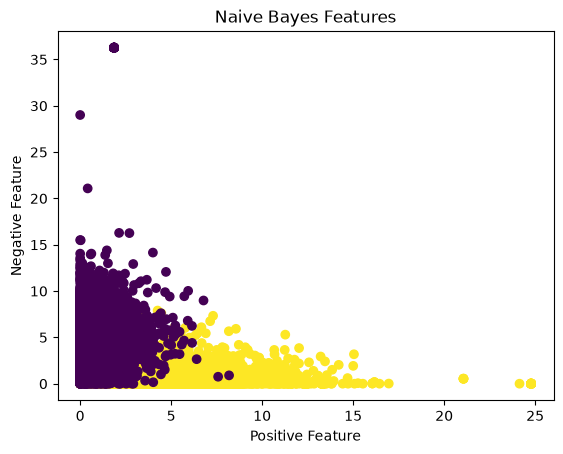

In [44]:
plt.scatter(
    df['positive'],
    df['negative'],
    c=df['sentiment']
)

plt.xlabel('Positive Feature')
plt.ylabel('Negative Feature')
plt.title('Naive Bayes Features')
plt.show()

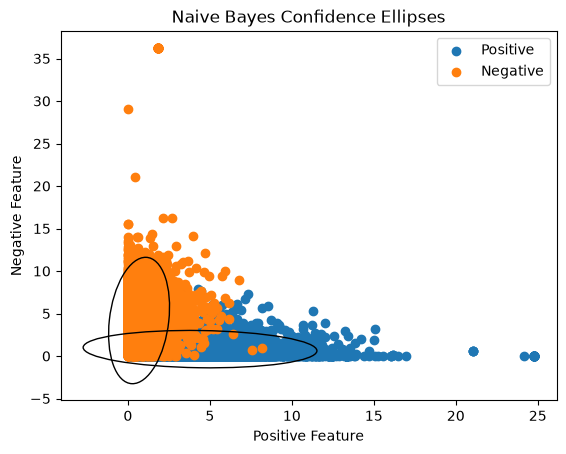

In [45]:
def confidence_ellipse(x, y, ax, n_std=2):
    covariance = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(
        eigenvectors[1, 0],
        eigenvectors[0, 0]
    ))

    width = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False
    )

    ax.add_patch(ellipse)


fig, ax = plt.subplots()

positive_data = df[df['sentiment'] == 1]
negative_data = df[df['sentiment'] == 0]

ax.scatter(
    positive_data['positive'],
    positive_data['negative'],
    label='Positive'
)

ax.scatter(
    negative_data['positive'],
    negative_data['negative'],
    label='Negative'
)

confidence_ellipse(
    positive_data['positive'],
    positive_data['negative'],
    ax,
    n_std=2
)

confidence_ellipse(
    negative_data['positive'],
    negative_data['negative'],
    ax,
    n_std=2
)

ax.set_xlabel('Positive Feature')
ax.set_ylabel('Negative Feature')
ax.set_title('Naive Bayes Confidence Ellipses')
ax.legend()

plt.show()

## Final Comments:
The Naive Bayes model was able to classify tweets based on the frequency of words
associated with positive and negative sentiments. The confidence ellipses help visualize how the positive and negative tweets are distributed in the feature space.